# Computing With Humanities
Presented by Suh Young Choi, inspired by Melanie Walsh

Humanistic computing (sometimes called digital humanities or humanistic data science) is an approach that brings together computational methods and humanistic inquiry. Rather than viewing technology and the humanities as separate domains, humanistic computing recognizes that the most meaningful insights often emerge when we combine the pattern-finding power of algorithms with the interpretive depth of humanistic thinking.

At its core, humanistic computing asks us to approach data work with questions that humanists have always asked: *What does this mean? Whose perspectives are represented? What historical forces shaped this? What are the ethical implications?* It tells us that technical skills are most powerful when paired with critical thinking about context, meaning, and human values. This approach is particularly important as data increasingly shapes decisions about everything from public policy to resource allocation, because it helps us understand not just what the data shows, but what it means for real people and communities.

Let's revisit some US national parks to see humanistic computing in action.

In [2]:
# !pip install -q folium mapclassify

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import folium

First, let's start by revisiting the National Parks plot from the previous lecture. Note that we have filtered out the U.S. Virgin Islands, Hawaii, and Alaska to restrict our data to the 48 contiguous (or mainland) states.

Text(0.5, 1.0, 'Number of Recreational Visits Across National Parks per State in 1980')

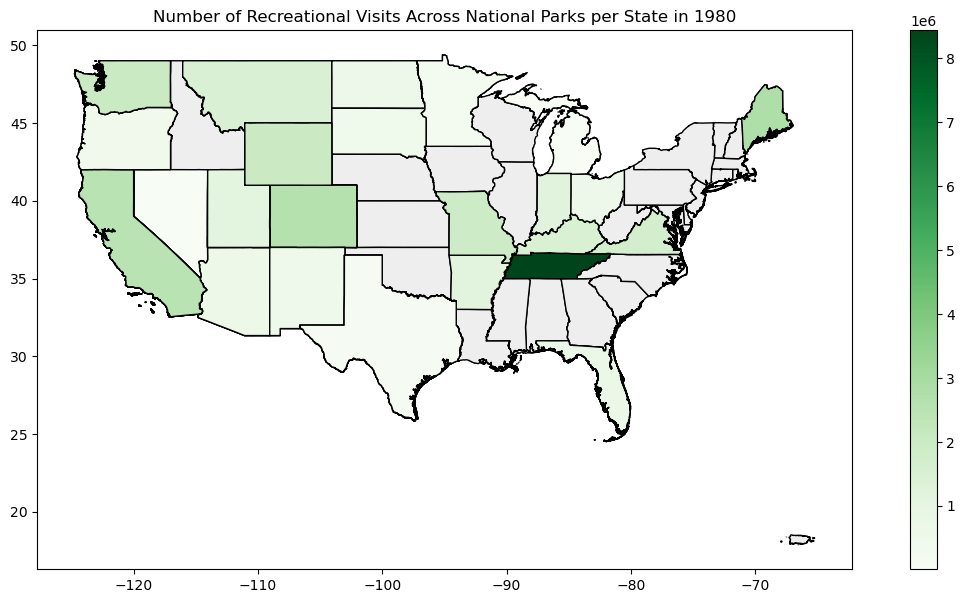

In [4]:
parks = pd.read_csv("US-National-Parks_RecreationVisits_1979-2024.csv")
# parks.head()

states = gpd.read_file("US_State_Boundaries.shp")
# states.head()

not_vi = states['NAME'] != 'U.S. Virgin Islands'
not_hi = states['NAME'] != 'Hawaii'
not_ak = states['NAME'] != 'Alaska'

states = states[not_vi & not_hi & not_ak]

parks_merged = states.merge(parks, left_on="STATE_ABBR", right_on="State", how="inner")

parks_1980 = parks_merged[parks_merged['Year'] == 1980]

fig, ax = plt.subplots(figsize=(15,7))

states.plot(ax=ax, color='#EEEEEE', edgecolor='black')
parks_1980.plot(ax=ax, column='RecreationVisits', cmap='Greens', edgecolor='black', legend=True)
plt.title("Number of Recreational Visits Across National Parks per State in 1980")

# plt.savefig("parks1980.png", bbox_inches='tight')

Wait a minute. There's an extra land mass off the southeast coast of Florida. Let's find out what that is (answer this question in Canvas!).

In [5]:
# How can you use the provided data to figure out what the mystery land mass is?
# Write your code here.


How could we have figured out the answer *without* using code?

- 

## Data as Representation, Not Reality

When we work with data, it's easy to treat numbers as objective facts about the world. But data is better described as a selective *representation* of reality shaped by human choices. Someone decided what to measure, how to categorize it, when to collect it, and what to leave out. A dataset about national parks, for instance, tells us how many parks exist and where they're located, but it doesn't tell us why those particular places became parks, whose lands they were originally, or what competing interests shaped those decisions.

This means that data can answer questions like "what" and "how many," but it struggles with "why" and "what does this mean." For example, let's find out how many national parks are there in the United States as of 2023.

In [6]:
len(parks[parks['Year'] == 2023])

63

The number 63 (the current count of U.S. national parks) is accurate, but without context, it's just a number. Any insight that we could draw from the data that we have (names, locations, years, number of visits) requires us to look beyond the data to really understand what they mean.

## Complementary Skills, Not Competing Ones

It's tempting to think of computational and humanistic approaches as opposite ends of a spectrum: numbers vs. narratives, objectivity vs. interpretation, science vs. humanities. But this framing misses the point. These approaches ask different kinds of questions and provide different kinds of answers, and both are essential for responsible data work.

Computational analysis gives us the "what", i.e., the patterns, trends, and quantifiable changes in our data. Humanistic inquiry gives us the "so what", i.e., the meanings, motivations, and implications of those patterns. When we combine them, we get a much richer understanding than either approach could provide alone. We can identify a trend computationally and then use contextual research to understand what forces created that trend and what consequences it might have.

The most impactful data science work happens at the intersection of these skills. Consider how different your understanding of national park creation becomes when you pair a simple count (computational) with research into the environmental legislation, Indigenous land rights movements, and conservation debates (humanistic) that shaped those decisions. Neither skill set is complete without the other.

## Historical and Social Context

Every piece of data exists within a web of historical, political, and cultural forces. Data is history. Historical context helps us understand not just what happened, but why it happened and what it meant to the people involved. The designation of a national park might reflect successful advocacy by environmental groups, political compromises between development and conservation interests, efforts to preserve Indigenous cultural sites, or attempts to protect ecosystems facing industrial threats. Without this context, we might see patterns in the data but completely misunderstand their significance.

Seeking context also means asking critical questions: *Whose voices were heard in these decisions? What communities were displaced or excluded? What economic interests were at play?* Understanding historical and social context transforms data from abstract numbers into stories about real people, real places, and real conflicts over resources and values.

### Let's find some additional context.

Let's start with a question we can answer computationally. What is the difference in number of national parks between 2023 and 1980?

(Note, this was a question that we came up with after noticing that only looking at data in 1980 meant that we might have missed data for parks that were established *after* 1980-- let's make sure that we didn't miss any!)

In [7]:
# How can we find the difference between the two years?

How would we find the names and locations of those parks?

In [8]:
park_first_year = parks.groupby(['ParkName', 'State', 'Region'])['Year'].min().reset_index()
park_first_year.columns = ['ParkName', 'State', 'Region', 'FirstYear']


#### Why Are National Parks Designated?

National parks aren't designated arbitrarily. Each designation represents a decision about what landscapes, ecosystems, and stories are worth preserving for future generations. The very first national park, Yellowstone National Park in Wyoming, was established in 1872 by President Ulysses S. Grant, and the National Park Service was created by President Woodrow Wilson in 1916. Understanding **why** parks are designated helps us see them as more than just tourist destinations or data points in a dataset.

Parks are typically designated to:

- **Preserve unique natural features**: Geological formations, ecosystems, or biodiversity that can't be found elsewhere
- **Protect cultural and historical significance**: Sites important to Indigenous peoples, American history, or cultural heritage
- **Respond to threats**: Areas facing development pressure, environmental degradation, or loss of habitat
- **Reflect changing values**: What we choose to protect reveals what we value as a society at that moment in time

The timing of a park's designation often tells us something about the political, social, and environmental concerns of that era. A park established in the 1980s or 1990s might reflect different priorities than one from the 1900s—perhaps more emphasis on conservation science, recognition of Indigenous connections to land, or response to specific environmental crises.

As we explore parks established between 1980 and 2023, consider: **What does the creation of these particular parks tell us about this period in American history?**

For example, 5 of the 8 national parks that we identified are in Alaska, and their first recorded visit years are all 1982. **Why is this?** Let's find out together. Here are some guiding questions:

- What keywords can be most useful for our search?
- How do we know that we are looking at a reputable source?
- What is the connection between what we have found through consulting our data vs. consulting other resources?

Choose one of the parks that was designated between 1980 and 2023 and use these guiding questions to look up more information about why this park was created. (Answer this in Canvas!)

## Positionality and Perspective

One of the most important insights from humanistic inquiry is that all knowledge is created from a particular perspective. When we examine data about national parks, we should ask: Who created this data, and what was their vantage point? Official park records reflect the perspectives of government agencies, which may emphasize certain narratives (natural beauty, recreation, conservation) while downplaying others (displacement of Indigenous peoples, conflicts over resource extraction, inequitable access).

Positionality reminds us to consider whose stories are told in our data and whose are missing. Many national parks were established on lands that Indigenous communities had inhabited and managed for thousands of years. The data may show when a park was "created," but from another perspective, those lands had been continuously inhabited and cared for long before their designation. Similarly, the history of who has had access to these parks—and who has felt welcome or unwelcome—shapes what visitation data really means.

Being attentive to positionality doesn't mean abandoning data or analysis. It means approaching our work with humility and curiosity about multiple perspectives. It means asking not just "what does the data show?" but "what does the data reflect about who had power to define and measure, and what might we be missing?" This critical lens makes our data work more accurate, more ethical, and more complete.

### Further Reading

#### Humanistic Computing

[1] [Anna Sollazzo & Quintin Cutts. "Towards a Theory of Humanistic Computing and How to Teach It".](https://dl.acm.org/doi/10.1145/3699538.3699559)

[2] [Bowen Jin. "Crash Course in Data: Data Humanism"](https://medium.com/aiskunks/crash-crouse-in-data-data-humanism-72e06a4f36a0)

[3] [Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/)

[4] [UW's Textual and Digital Studies program](https://txtds.uw.edu/index.php/programs/)

[5] [UW's Science, Technology, and Society Studies graduate certificate](https://depts.washington.edu/stsst/curriculum/)

#### National Parks and History

[1] [Library of Congress. "Brief History of the National Parks"](https://www.loc.gov/collections/national-parks-maps/articles-and-essays/brief-history-of-the-national-parks/)

[2] [National Parks Conservation Association. "Spotlight: National Parks Are Native Lands"](https://www.npca.org/case-studies/national-parks-are-native-lands)

[3] [National Park Foundation. "Native American History & Culture in Parks"](https://www.nationalparks.org/theme/native-american-history-culture-in-parks)

[4] [Rolf Diamant and Ethan Carr "Telling the Real Stories Behind the Birth of America's National Parks"](https://lithub.com/telling-the-real-stories-behind-the-birth-of-americas-national-parks/)

[5] [National Park Service: "Alaska National Interest Lands Conservation Act"](https://www.nps.gov/locations/alaska/anilca.htm)